In [75]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [76]:
df=pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [77]:
variable=['Sex','ChestPainType','RestingECG','FastingBS','ExerciseAngina','ST_Slope']

In [78]:
data=pd.get_dummies(data=df,prefix=variable,columns=variable)
data.head()
y=data['HeartDisease']
X=data.drop(columns=["HeartDisease"])


In [93]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1234)
print(y_train.shape)

(734,)


In [80]:
max_Depth=[2, 4, 8, 16, 32, 64, None]
min_split_list=[2,10, 30, 50, 100, 200, 300, 700]
n_estimator=[10,50,100,500]


In [81]:
train_acc=[]
test_acc=[]

for max_depth in max_Depth:
    model=RandomForestClassifier(max_depth=max_depth,random_state=1234)
    model.fit(x_train,y_train)
    y_cap_test=model.predict(x_test)
    y_cap_train=model.predict(x_train)
    acc_test=accuracy_score(y_test,y_cap_test)
    acc_train=accuracy_score(y_train,y_cap_train)
    train_acc.append(acc_train)
    test_acc.append(acc_test)



[0.03438574 0.01255775 0.06647613 0.11413043 0.11956522 0.11956522
 0.11956522]


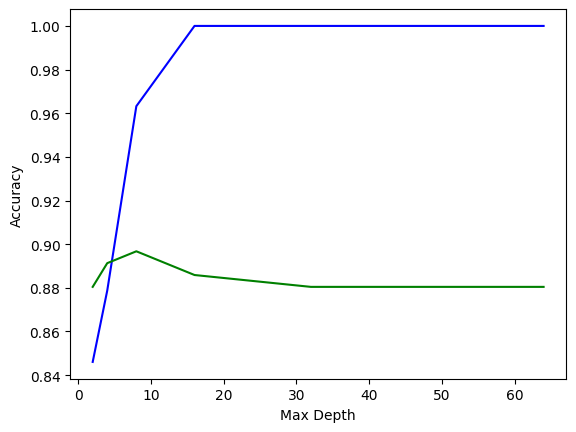

In [82]:
diff=[]
plt.plot(max_Depth,train_acc,color='b')
plt.plot(max_Depth,test_acc,color='g')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
train_acc=np.array(train_acc)
test_acc=np.array(test_acc)
diff=np.abs(train_acc-test_acc)
print(diff)
max_depth=np.argmin(diff)

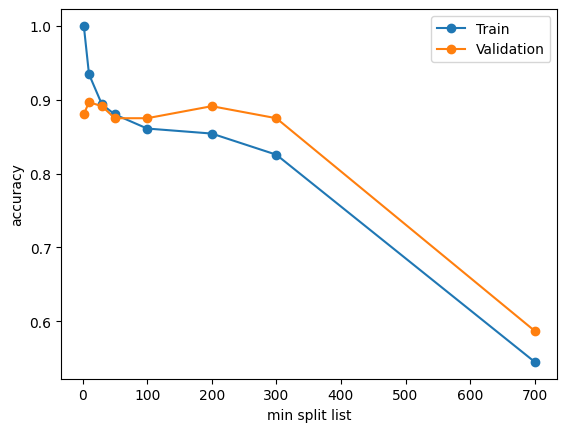

In [108]:
y_train_acc=[]
y_test_acc=[]
for min_split in min_split_list:
    model=RandomForestClassifier(min_samples_split=min_split,random_state=1234)
    model.fit(x_train,y_train)
    y_train_cap=model.predict(x_train)
    y_test_cap=model.predict(x_test)
    train_acc=accuracy_score(y_train,y_train_cap)
    test_acc=accuracy_score(y_test,y_test_cap)
    y_train_acc.append(train_acc)
    y_test_acc.append(test_acc)
    

plt.plot(min_split_list,y_train_acc,marker='o')
plt.plot(min_split_list,y_test_acc,marker='o')
plt.xlabel('min split list')
plt.ylabel('accuracy')
plt.legend(['Train','Validation'])

In [120]:
train_list=[]
test_list=[]
n_estimator_list=[10,50,100,500]
for estimator in n_estimator_list:
    model=RandomForestClassifier(n_estimators=estimator,random_state=1234)
    model.fit(x_train,y_train)
    y_test_cap=model.predict(x_test)
    y_train_cap=model.predict(x_train)
    train_acc=accuracy_score(y_train_cap,y_train)
    test_acc=accuracy_score(y_test_cap,y_test)
    train_list.append(train_acc)
    test_list.append(test_acc)

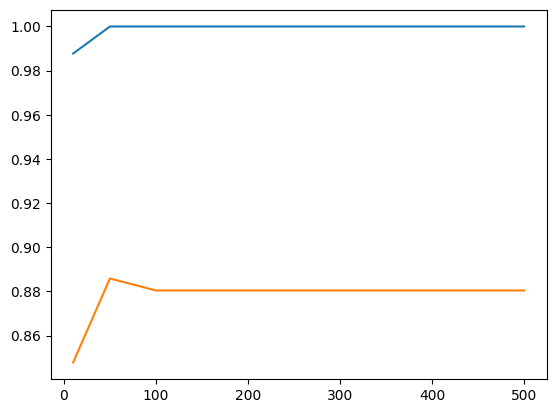

In [122]:

plt.plot(n_estimator_list,train_list)
plt.plot(n_estimator_list,test_list)
